# 递归 Burg 变体 — 440Hz 固定频率 Vocoder 测试

从 `recursive_burg_variants.ipynb` 中提取 **11 种**递归 Burg 变体，测试其在 **440Hz（A4 标准音）**固定频率 δ 串载波 Vocoder 中的表现。

## 测试变体

| # | 变体 | 核心特点 |
|---|------|---------|
| 1 | **标准递归 Burg** | 指数遗忘，逐采样更新 k |
| 2 | **间隔计算** | 累积量逐采样更新，k 每 N 采样重算 |
| 3 | **CIC 矩形窗** | 滑动矩形窗替代指数遗忘，O(1) 更新 |
| 4 | **Sign-Burg** | A_m 用符号乘积 sgn(f)·sgn(b) 更新 |
| 5 | **NLMS 格型** | 固定步长、功率归一化梯度下降 |
| 6 | **变遗忘因子** | 误差自适应 λ |
| 7 | **动量 Burg** | RLS 更新 + 梯度动量平滑 |
| 8 | **岭回归 Burg** | B_m 叠加正则化 delta，抑制噪声 |
| 9 | **双时间尺度** | 快 λ 格型传播 + 慢 λ 估计 k |
| 10 | **中值滤波 Burg** | k 的滑动中值滤波 |
| 11 | **自适应 NLMS** | 梯度符号一致性自适应步长 |


## 参考

- `recursive_burg_vocoder.ipynb` — 原 Vocoder 测试
- `recursive_burg_variants.ipynb` — 变体算法定义与研究

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from scipy.signal import freqz, lfilter, spectrogram
from IPython.display import Audio, display

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False
np.random.seed(42)

print("库导入完成")


库导入完成


---
## 1. 读取 wormhole.wav 前 1 秒


In [9]:
# ------------------------------------------------------------
# 读取 wormhole.wav 前 1 秒
# ------------------------------------------------------------
WAV_PATH = r"c:\Users\Kawai\Desktop\a5632645\qwqdsp\qwqdsp\tests\work_dir\input\wormhole.wav"
x_full, fs = sf.read(WAV_PATH)

if x_full.ndim > 1:
    x_full = x_full[:, 0]

N = int(1.0 * fs)
x = x_full[:N].copy()
t = np.arange(N) / fs

print(f"采样率: {fs} Hz, 长度: {N} 样本 ({N/fs:.2f} 秒)")

# 预加重
pre_emph = 0.97
x_pre = np.append(x[0], x[1:] - pre_emph * x[:-1])
print(f"信号范围: [{x.min():.4f}, {x.max():.4f}]")


采样率: 48000 Hz, 长度: 48000 样本 (1.00 秒)
信号范围: [-0.5369, 0.4222]


---
## 2. 算法函数定义（6 种变体）


In [10]:
# ------------------------------------------------------------
# 2a. 分块 Burg（参考基准）
# ------------------------------------------------------------
def block_burg(x, order):
    N = len(x)
    f = x.copy().astype(np.float64)
    b = x.copy().astype(np.float64)
    k = np.zeros(order)
    a = np.array([1.0])
    for m in range(order):
        num = 2.0 * np.sum(f[m+1:] * b[m:N-1])
        den = np.sum(f[m+1:]**2 + b[m:N-1]**2)
        k[m] = -num / den if den > 1e-30 else 0.0
        f_next = f.copy()
        b_next = b.copy()
        f_next[m+1:] = f[m+1:] + k[m] * b[m:N-1]
        b_next[m+1:] = b[m:N-1] + k[m] * f[m+1:]
        f, b = f_next, b_next
        a = np.pad(a, (0, 1), mode='constant')
        a_prev = a.copy()
        a[-1] = k[m]
        for i in range(1, m + 1):
            a[i] = a_prev[i] + k[m] * a_prev[m + 1 - i]
    return a, f.copy(), k


# ------------------------------------------------------------
# 2b. Levinson 递推
# ------------------------------------------------------------
def levinson_from_k(k):
    P = len(k)
    a = np.ones(P + 1)
    for m in range(P):
        k_m = k[m]
        a_prev = a.copy()
        a[m + 1] = k_m
        for i in range(1, m + 1):
            a[i] = a_prev[i] + k_m * a_prev[m - i + 1]
    return a


# ------------------------------------------------------------
# 2c. 时变 LPC 合成
# ------------------------------------------------------------
def lpc_synth_tv(excitation, a_history):
    N = len(excitation)
    P = a_history.shape[1] - 1
    y = np.zeros(N, dtype=np.float64)
    for n in range(N):
        a = a_history[n]
        y[n] = excitation[n]
        for m in range(1, P + 1):
            if n >= m:
                y[n] -= a[m] * y[n - m]
    return y


# ------------------------------------------------------------
# 2d. 固定频率 δ 串
# ------------------------------------------------------------
def fixed_freq_delta_train(freq_hz, n_samples, fs):
    period = int(fs / freq_hz)
    exc = np.zeros(n_samples)
    exc[::period] = 1.0
    return exc


def fixed_freq_excitation(freq_hz, n_samples, fs, frame_energy, frame_len, hop_len):
    exc = fixed_freq_delta_train(freq_hz, n_samples, fs)
    win = np.hanning(frame_len)
    n_frames = 1 + (n_samples - frame_len) // hop_len
    exc_env = np.zeros(n_samples)
    for idx in range(n_frames):
        s = idx * hop_len
        e_frame = min(s + frame_len, n_samples)
        seg = slice(s, e_frame)
        frame_exc = exc[seg].copy()
        rms_target = frame_energy[idx]
        rms_exc = np.sqrt(np.mean(frame_exc**2) + 1e-30)
        if rms_exc > 1e-30 and rms_target > 1e-30:
            frame_exc *= rms_target / rms_exc
        exc_env[seg] += frame_exc * win[:e_frame - s]
    return exc_env


In [11]:
# ------------------------------------------------------------
# 2e. 变体 1 — 标准递归 Burg（指数遗忘）
# ------------------------------------------------------------
def burg_standard(x, order, lam=0.995, eps=1e-6):
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    A = np.zeros(order, dtype=dtype)
    B = np.full(order, eps, dtype=dtype)
    k = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)
    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            A[m] = lam * A[m] + f_m1_t * b_m1_t1
            B[m] = lam * B[m] + f_m1_t**2 + b_m1_t1**2
            k[m] = -2.0 * A[m] / B[m] if B[m] > 1e-30 else 0.0
            k[m] = np.clip(k[m], -0.999, 0.999)
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    return k_history, e


# ------------------------------------------------------------
# 2f. 变体 2 — 间隔计算（k 每 N 采样重算）
# ------------------------------------------------------------
def burg_interval(x, order, lam=0.995, eps=1e-6, update_interval=12):
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    A = np.zeros(order, dtype=dtype)
    B = np.full(order, eps, dtype=dtype)
    k = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)
    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            A[m] = lam * A[m] + f_m1_t * b_m1_t1
            B[m] = lam * B[m] + f_m1_t**2 + b_m1_t1**2
            if t % update_interval == 0:
                k[m] = -2.0 * A[m] / B[m] if B[m] > 1e-30 else 0.0
                k[m] = np.clip(k[m], -0.999, 0.999)
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    return k_history, e


# ------------------------------------------------------------
# 2g. 变体 3 — CIC 矩形窗
# ------------------------------------------------------------
def burg_cic(x, order, window_len, eps=1e-6):
    N = len(x)
    L = int(window_len)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    A = np.zeros(order, dtype=dtype)
    B = np.full(order, eps, dtype=dtype)
    f_ring = np.zeros((order, L), dtype=dtype)
    b_ring = np.zeros((order, L), dtype=dtype)
    ring_pos = 0
    k = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)
    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            A[m] += f_m1_t * b_m1_t1
            B[m] += f_m1_t**2 + b_m1_t1**2
            if t >= L:
                f_old = f_ring[m, ring_pos]
                b_old = b_ring[m, ring_pos]
                A[m] -= f_old * b_old
                B[m] -= f_old**2 + b_old**2
            f_ring[m, ring_pos] = f_m1_t
            b_ring[m, ring_pos] = b_m1_t1
            k[m] = -2.0 * A[m] / B[m] if B[m] > 1e-30 else 0.0
            k[m] = np.clip(k[m], -0.999, 0.999)
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t
        ring_pos = (ring_pos + 1) % L
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    return k_history, e


# ------------------------------------------------------------
# 2h. 变体 4 — Sign-Burg（符号更新 A_m）
# ------------------------------------------------------------
def burg_sign(x, order, lam=0.995, eps=1e-6):
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    A = np.zeros(order, dtype=dtype)
    B = np.full(order, eps, dtype=dtype)
    k = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)
    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            A[m] = lam * A[m] + np.sign(f_m1_t) * np.sign(b_m1_t1)
            B[m] = lam * B[m] + f_m1_t**2 + b_m1_t1**2
            k[m] = -2.0 * A[m] / B[m] if B[m] > 1e-30 else 0.0
            k[m] = np.clip(k[m], -0.999, 0.999)
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    return k_history, e


# ------------------------------------------------------------
# 2i. 变体 5 — NLMS 格型（固定步长梯度下降）
# ------------------------------------------------------------
def burg_nlms(x, order, mu=0.01, eps=1e-6):
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    P = np.full(order, eps, dtype=dtype)
    k = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)
    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            P[m] = 0.99 * P[m] + (1 - 0.99) * (f_m1_t**2 + b_m1_t1**2)
            grad = f_m1_t * b_m1_t1
            k[m] -= mu * grad / (P[m] + eps)
            k[m] = np.clip(k[m], -0.999, 0.999)
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    return k_history, e


# ------------------------------------------------------------
# 2j. 变体 6 — 变遗忘因子
# ------------------------------------------------------------
def burg_var_forget(x, order, lam_inf=0.999, alpha=10.0, eps=1e-6):
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    A = np.zeros(order, dtype=dtype)
    B = np.full(order, eps, dtype=dtype)
    k = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)
    smooth_e = 0.0
    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        # 根据预测误差调整遗忘因子
        pred_err = f_curr[0]
        smooth_e = 0.9 * smooth_e + 0.1 * abs(pred_err)
        lam_t = lam_inf + (1.0 - lam_inf) * np.exp(-alpha * smooth_e)
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            A[m] = lam_t * A[m] + f_m1_t * b_m1_t1
            B[m] = lam_t * B[m] + f_m1_t**2 + b_m1_t1**2
            k[m] = -2.0 * A[m] / B[m] if B[m] > 1e-30 else 0.0
            k[m] = np.clip(k[m], -0.999, 0.999)
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    return k_history, e


# ------------------------------------------------------------
# 2k. 变体 7 — 动量 Burg
# ------------------------------------------------------------
def burg_momentum(x, order, lam=0.995, mu=0.3, beta=0.8, eps=1e-6):
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    A = np.zeros(order, dtype=dtype)
    B = np.full(order, eps, dtype=dtype)
    k = np.zeros(order, dtype=dtype)
    k_prev = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)
    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            A[m] = lam * A[m] + f_m1_t * b_m1_t1
            B[m] = lam * B[m] + f_m1_t**2 + b_m1_t1**2
            k_raw = -2.0 * A[m] / B[m] if B[m] > 1e-30 else 0.0
            k_raw = np.clip(k_raw, -0.999, 0.999)
            k_new = k[m] + mu * (k_raw - k[m]) + beta * (k[m] - k_prev[m])
            k_prev[m] = k[m]
            k[m] = np.clip(k_new, -0.999, 0.999)
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    return k_history, e


# ------------------------------------------------------------
# 2l. 变体 8 — 岭回归 Burg（正则化分母）
# ------------------------------------------------------------
def burg_ridge(x, order, lam=0.995, delta=0.1, eps=1e-6):
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    A = np.zeros(order, dtype=dtype)
    B = np.full(order, eps, dtype=dtype)
    k = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)
    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            A[m] = lam * A[m] + f_m1_t * b_m1_t1
            B[m] = lam * B[m] + f_m1_t**2 + b_m1_t1**2
            k[m] = -2.0 * A[m] / (B[m] + delta) if B[m] + delta > 1e-30 else 0.0
            k[m] = np.clip(k[m], -0.999, 0.999)
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    return k_history, e


# ------------------------------------------------------------
# 2m. 变体 9 — 双时间尺度
# ------------------------------------------------------------
def burg_dual(x, order, lam_fast=0.95, lam_slow=0.998, eps=1e-6):
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    A = np.zeros(order, dtype=dtype)
    B = np.full(order, eps, dtype=dtype)
    A_fast = np.zeros(order, dtype=dtype)
    B_fast = np.full(order, eps, dtype=dtype)
    k = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)
    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            A[m] = lam_slow * A[m] + f_m1_t * b_m1_t1
            B[m] = lam_slow * B[m] + f_m1_t**2 + b_m1_t1**2
            k[m] = -2.0 * A[m] / B[m] if B[m] > 1e-30 else 0.0
            k[m] = np.clip(k[m], -0.999, 0.999)
            A_fast[m] = lam_fast * A_fast[m] + f_m1_t * b_m1_t1
            B_fast[m] = lam_fast * B_fast[m] + f_m1_t**2 + b_m1_t1**2
            k_fast = -2.0 * A_fast[m] / B_fast[m] if B_fast[m] > 1e-30 else 0.0
            k_fast = np.clip(k_fast, -0.999, 0.999)
            f_curr[m + 1] = f_m1_t + k_fast * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k_fast * f_m1_t
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    return k_history, e


# ------------------------------------------------------------
# 2n. 变体 10 — 中值滤波 Burg
# ------------------------------------------------------------
def burg_median(x, order, lam=0.995, median_len=11, eps=1e-6):
    from collections import deque
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    A = np.zeros(order, dtype=dtype)
    B = np.full(order, eps, dtype=dtype)
    k = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)
    windows = [deque(maxlen=median_len) for _ in range(order)]
    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            A[m] = lam * A[m] + f_m1_t * b_m1_t1
            B[m] = lam * B[m] + f_m1_t**2 + b_m1_t1**2
            k_raw = -2.0 * A[m] / B[m] if B[m] > 1e-30 else 0.0
            k_raw = np.clip(k_raw, -0.999, 0.999)
            windows[m].append(k_raw)
            k[m] = np.median(list(windows[m]))
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    return k_history, e


# ------------------------------------------------------------
# 2o. 变体 11 — 自适应 NLMS（梯度符号一致性）
# ------------------------------------------------------------
def burg_adanlms(x, order, mu_0=0.01, eps=1e-6):
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    k = np.zeros(order, dtype=dtype)
    P = np.full(order, eps, dtype=dtype)
    lam_p = 0.9
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)
    sign_consistency = np.zeros(order, dtype=dtype)
    mu = np.full(order, mu_0, dtype=dtype)
    mu_max = 0.1
    mu_min = 0.001
    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t
            grad = f_curr[m + 1] * b_m1_t1 + b_curr[m + 1] * f_m1_t
            P[m] = lam_p * P[m] + (1 - lam_p) * (f_m1_t**2 + b_m1_t1**2)
            if t > 0:
                same_sign = (grad * k_history[t-1, m]) > 0
                sign_consistency[m] = 0.9 * sign_consistency[m] + 0.1 * same_sign
            mu[m] = mu_0 + (mu_max - mu_0) * sign_consistency[m]
            mu[m] = np.clip(mu[m], mu_min, mu_max)
            k[m] -= mu[m] * grad / (P[m] + eps)
            k[m] = np.clip(k[m], -0.999, 0.999)
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    return k_history, e


def lpc_envelope(a, fs, n_fft=4096):
    w, h = freqz(1.0, a, worN=n_fft, fs=fs)
    env_db = 20.0 * np.log10(np.abs(h) + 1e-30)
    return w, env_db


print("所有 11 种变体函数定义完成")

所有 11 种变体函数定义完成


---
## 3. 440Hz 固定频率 Vocoder 测试


In [12]:
# ------------------------------------------------------------
# 3a. 参数
# ------------------------------------------------------------
P = 36
TAU_MS = 10
frame_ms = 30
hop_ms = 10
frame_len = int(frame_ms * fs / 1000)
hop_len = int(hop_ms * fs / 1000)
n_frames = 1 + (N - frame_len) // hop_len
lam = np.exp(-1.0 / ((TAU_MS / 1000.0) * fs))

print(f"LPC 阶数: P = {P}")
print(f"遗忘时间: τ = {TAU_MS}ms (λ = {lam:.6f})")
print(f"帧长/帧移: {frame_len}/{hop_len}")

# 帧 RMS（载波幅度包络用）
frame_rms = np.zeros(n_frames)
for idx in range(n_frames):
    s = idx * hop_len
    e_frame = min(s + frame_len, N)
    frame_rms[idx] = np.sqrt(np.mean(x[s:e_frame]**2) + 1e-30)

# ------------------------------------------------------------
# 3b. 分块 Burg 参考分析
# ------------------------------------------------------------
win = np.hanning(frame_len)
a_block_frames = np.zeros((n_frames, P + 1))
for idx in range(n_frames):
    s = idx * hop_len
    frame = x_pre[s:s + frame_len] * win
    a_f, _, _ = block_burg(frame, P)
    a_block_frames[idx] = a_f


def block_burg_synth(excitation, a_frames, n_frames, frame_len, hop_len, win):
    N = len(excitation)
    synth = np.zeros(N)
    for idx in range(n_frames):
        s = idx * hop_len
        e_frame = min(s + frame_len, N)
        frame_synth = lfilter([1.0], a_frames[idx], excitation[s:e_frame])
        synth[s:e_frame] += frame_synth * win[:e_frame - s]
    return synth


# ------------------------------------------------------------
# 3c. 生成 440Hz 载波
# ------------------------------------------------------------
FREQ = 440.0
exc_440 = fixed_freq_excitation(FREQ, N, fs, frame_rms, frame_len, hop_len)
print(f"440Hz 固定频率载波生成完成")

# 分块 Burg 参考合成
synth_block = block_burg_synth(exc_440, a_block_frames, n_frames, frame_len, hop_len, win)
print("分块 Burg 参考合成完成")


# ------------------------------------------------------------
# 3d. 运行所有 11 种变体
# ------------------------------------------------------------
variants = [
    ("标准递归 Burg", lambda: burg_standard(x_pre, P, lam=lam)),
    ("间隔计算 (每12采样)", lambda: burg_interval(x_pre, P, lam=lam, update_interval=12)),
    ("CIC 矩形窗 (10ms)", lambda: burg_cic(x_pre, P, window_len=int(TAU_MS*fs/1000))),
    ("Sign-Burg", lambda: burg_sign(x_pre, P, lam=lam)),
    ("NLMS 格型 (μ=0.01)", lambda: burg_nlms(x_pre, P, mu=0.01)),
    ("变遗忘因子", lambda: burg_var_forget(x_pre, P, lam_inf=0.999, alpha=10.0)),
    ("动量 Burg", lambda: burg_momentum(x_pre, P, lam=lam, mu=0.3, beta=0.7)),
    ("岭回归 Burg (δ=0.1)", lambda: burg_ridge(x_pre, P, lam=lam, delta=0.1)),
    ("双时间尺度", lambda: burg_dual(x_pre, P, lam_fast=0.95, lam_slow=0.998)),
    ("中值滤波 Burg (L=11)", lambda: burg_median(x_pre, P, lam=lam, median_len=11)),
    ("自适应 NLMS", lambda: burg_adanlms(x_pre, P, mu_0=0.02)),
]

results = {}  # {name: synth_signal}
k_histories = {}  # {name: k_history}

for name, func in variants:
    print(f"运行: {name} ...", end=" ")
    k_hist, _ = func()
    k_histories[name] = k_hist

    a_hist = np.zeros((N, P + 1))
    for n in range(N):
        a_hist[n] = levinson_from_k(k_hist[n])

    synth = lpc_synth_tv(exc_440, a_hist)

    results[name] = synth

    print("完成")

print(f"\n全部 11 种变体合成完成")


LPC 阶数: P = 36
遗忘时间: τ = 10ms (λ = 0.997919)
帧长/帧移: 1440/480
440Hz 固定频率载波生成完成
分块 Burg 参考合成完成
运行: 标准递归 Burg ... 完成
运行: 间隔计算 (每12采样) ... 完成
运行: CIC 矩形窗 (10ms) ... 完成
运行: Sign-Burg ... 

C:\Users\Kawai\AppData\Local\Temp\ipykernel_10616\2206571633.py:54: RuntimeWarning: overflow encountered in scalar multiply
  y[n] -= a[m] * y[n - m]
C:\Users\Kawai\AppData\Local\Temp\ipykernel_10616\2206571633.py:54: RuntimeWarning: invalid value encountered in scalar subtract
  y[n] -= a[m] * y[n - m]


完成
运行: NLMS 格型 (μ=0.01) ... 完成
运行: 变遗忘因子 ... 完成
运行: 动量 Burg ... 完成
运行: 岭回归 Burg (δ=0.1) ... 完成
运行: 双时间尺度 ... 完成
运行: 中值滤波 Burg (L=11) ... 完成
运行: 自适应 NLMS ... 完成

全部 11 种变体合成完成


---
## 4. 波形对比


C:\Users\Kawai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\ticker.py:2178: RuntimeWarning: overflow encountered in multiply
  steps = self._extended_steps * scale


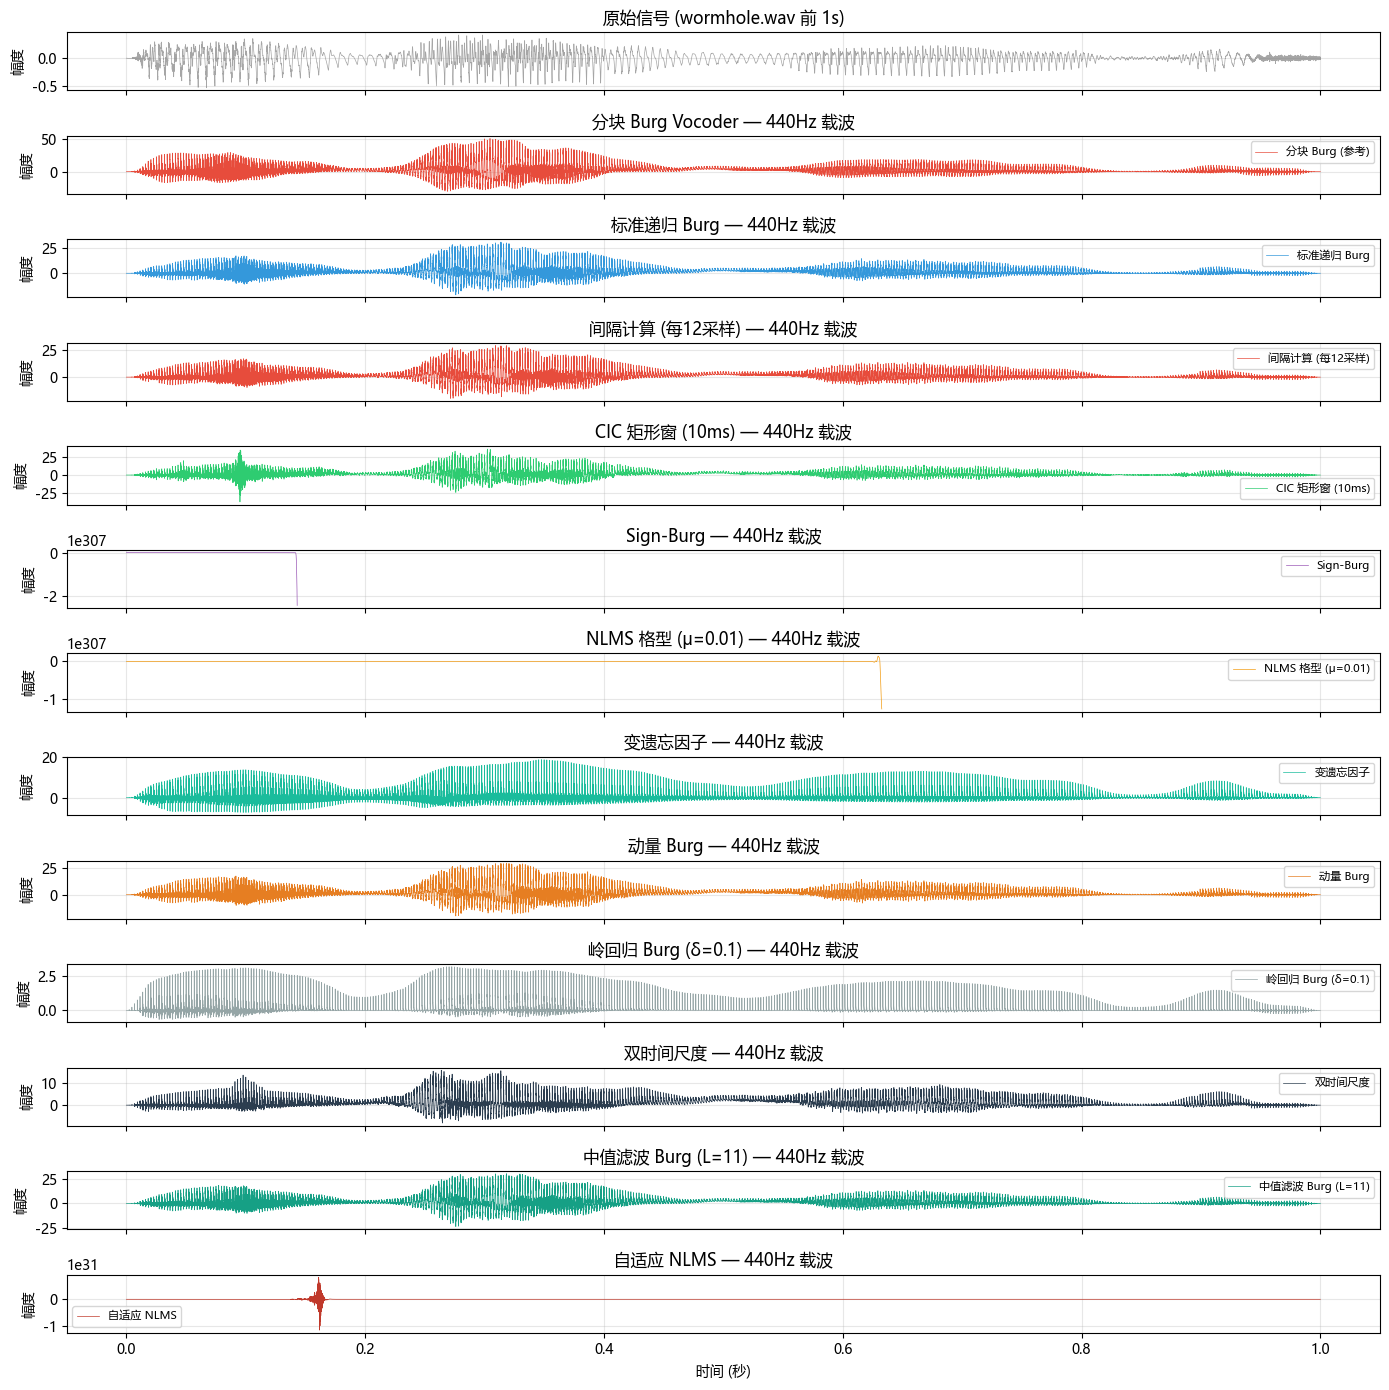

In [13]:
# ------------------------------------------------------------
# 4a. 波形对比：原始 vs 分块 Burg vs 11 种变体
# ------------------------------------------------------------
n_variants = len(variants)
fig, axes = plt.subplots(n_variants + 2, 1, figsize=(14, 14), sharex=True)

colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c',
          '#e67e22', '#95a5a6', '#2c3e50', '#16a085', '#c0392b']

# 原始
ax0 = axes[0]
ax0.plot(t, x, color='gray', linewidth=0.5, alpha=0.7)
ax0.set_ylabel('幅度')
ax0.set_title(f'原始信号 (wormhole.wav 前 1s)')
ax0.grid(True, alpha=0.3)

# 分块 Burg
ax1 = axes[1]
ax1.plot(t, synth_block, color='#e74c3c', linewidth=0.5, label='分块 Burg (参考)')
ax1.set_ylabel('幅度')
ax1.set_title(f'分块 Burg Vocoder — 440Hz 载波')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=8)

# 各变体
for i, (name, _) in enumerate(variants):
    ax = axes[i + 2]
    ax.plot(t, results[name], linewidth=0.5, color=colors[i % len(colors)], label=name)
    ax.set_ylabel('幅度')
    ax.set_title(f'{name} — 440Hz 载波')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[-1].set_xlabel('时间 (秒)')
plt.tight_layout()
plt.show()


---
## 5. 语谱图对比


C:\Users\Kawai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\signal\_spectral_py.py:2126: RuntimeWarning: overflow encountered in multiply
  result = np.conjugate(result) * result
C:\Users\Kawai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\signal\_spectral_py.py:2128: RuntimeWarning: invalid value encountered in multiply
  result *= scale


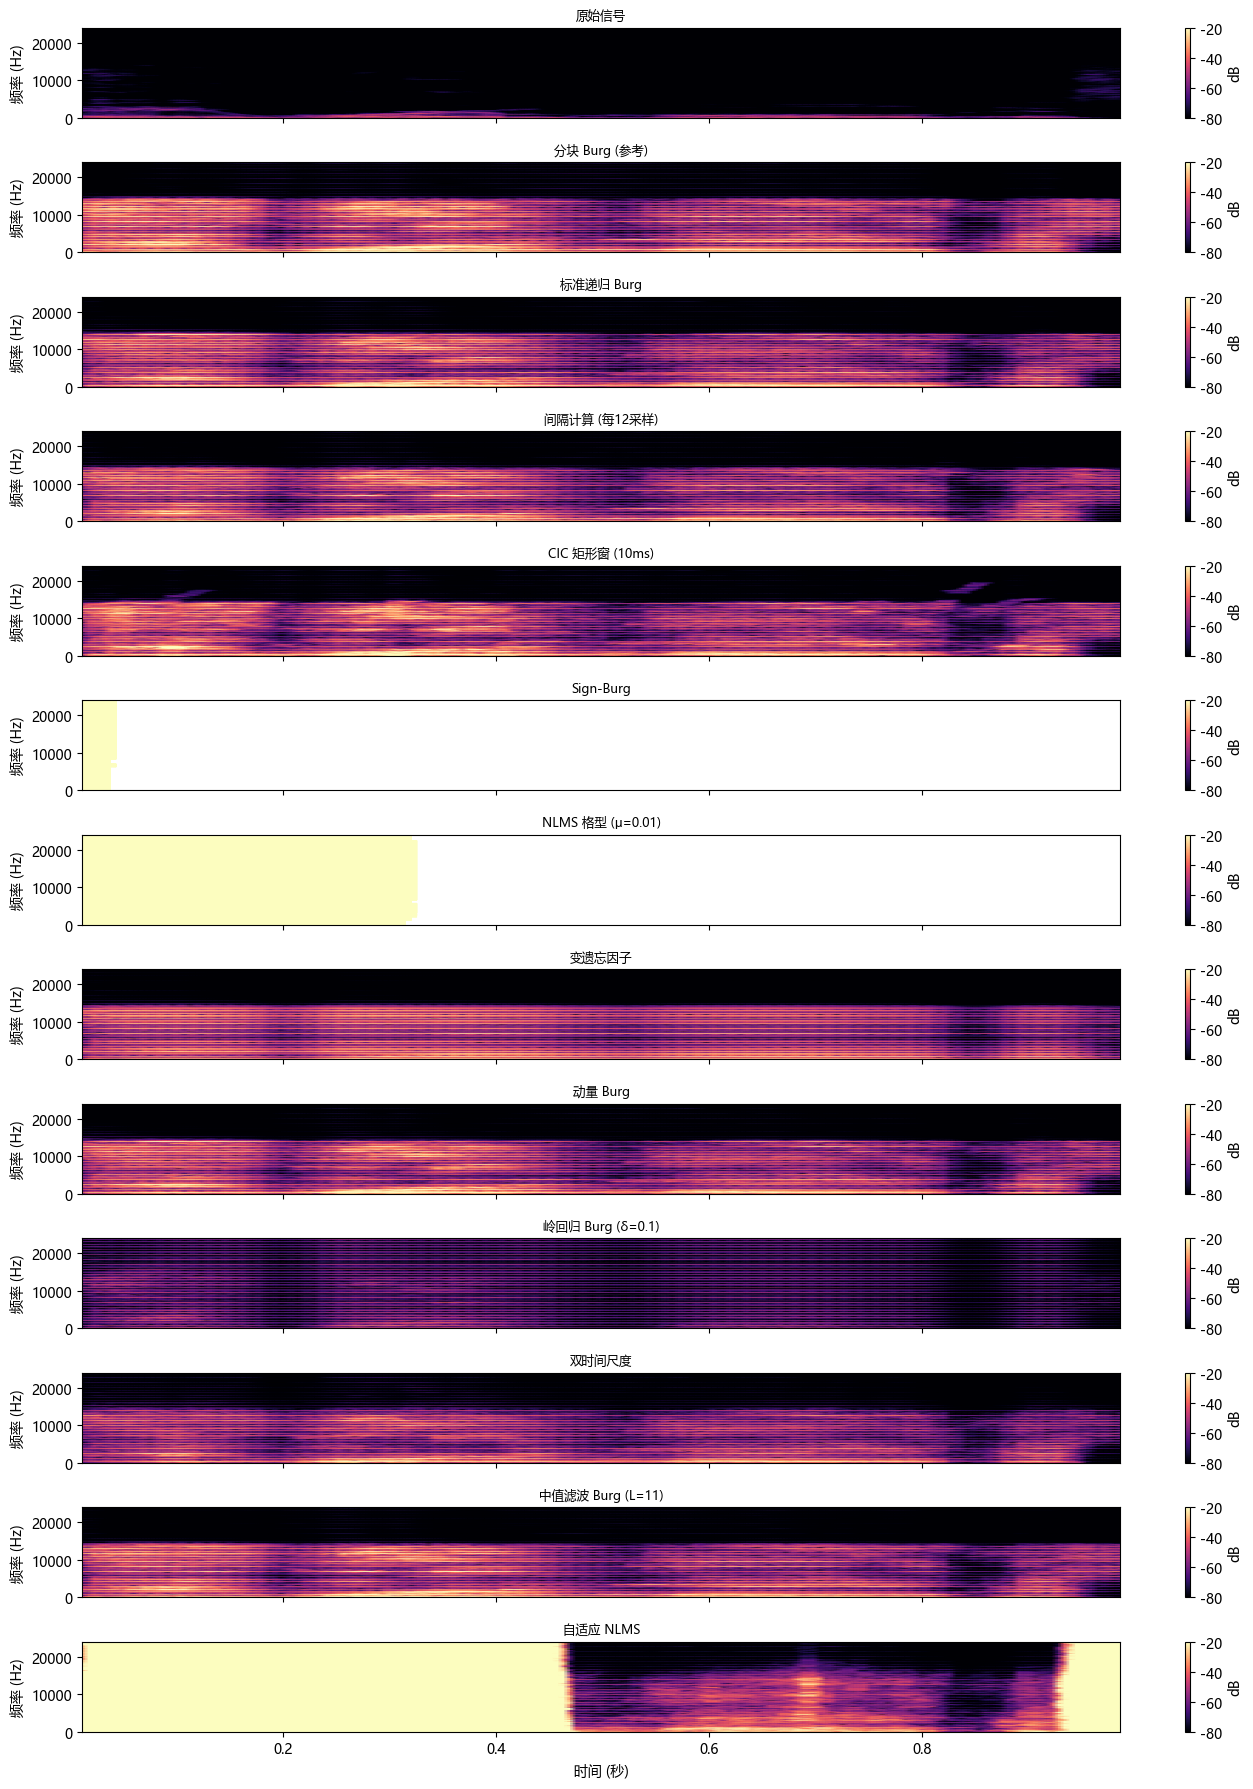

In [14]:
# ------------------------------------------------------------
# 5a. 语谱图：原始 + 分块 + 11 种变体
# ------------------------------------------------------------
n_fft_spec = 1024
hop_len_spec = 256
vmin_db, vmax_db = -80, -20

spec_labels = [("原始信号", x), ("分块 Burg (参考)", synth_block)]
for name, _ in variants:
    spec_labels.append((name, results[name]))

fig, axes = plt.subplots(len(spec_labels), 1, figsize=(14, 18), sharex=True)

for idx, (label, signal) in enumerate(spec_labels):
    ax = axes[idx]
    f_s, t_s, Sxx = spectrogram(signal, fs, nperseg=n_fft_spec,
                                 noverlap=n_fft_spec - hop_len_spec)
    Sxx_db = 10 * np.log10(Sxx + 1e-30)
    im = ax.pcolormesh(t_s, f_s, Sxx_db, shading='gouraud',
                       cmap='magma', vmin=vmin_db, vmax=vmax_db)
    ax.set_ylabel('频率 (Hz)')
    ax.set_title(f'{label}', fontsize=9)
    ax.set_ylim(0, fs / 2)
    fig.colorbar(im, ax=ax, label='dB')

axes[-1].set_xlabel('时间 (秒)')
plt.tight_layout()
plt.show()


---
## 6. 定量评价


=== 440Hz 固定频率载波 — SNR 对比 ===

方法                     SNR (dB)     高频SNR (dB)     
-------------------------------------------------
分块 Burg (参考)           -35.24       -46.82         
标准递归 Burg              -30.76       -42.09         
间隔计算 (每12采样)           -30.54       -41.91         
CIC 矩形窗 (10ms)         -31.63       -43.92         
Sign-Burg              nan          nan            
NLMS 格型 (μ=0.01)       nan          nan            
变遗忘因子                  -25.66       -40.93         
动量 Burg                -30.89       -42.41         
岭回归 Burg (δ=0.1)       -6.60        -22.93         
双时间尺度                  -25.54       -35.39         
中值滤波 Burg (L=11)       -31.16       -42.79         
自适应 NLMS               -605.59      -623.70        

=== 高频段 SNR 排名 ===


C:\Users\Kawai\AppData\Local\Temp\ipykernel_10616\836787000.py:6: RuntimeWarning: overflow encountered in square
  return 10 * np.log10(np.sum(original**2) / (np.sum(noise**2) + 1e-30))
C:\Users\Kawai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


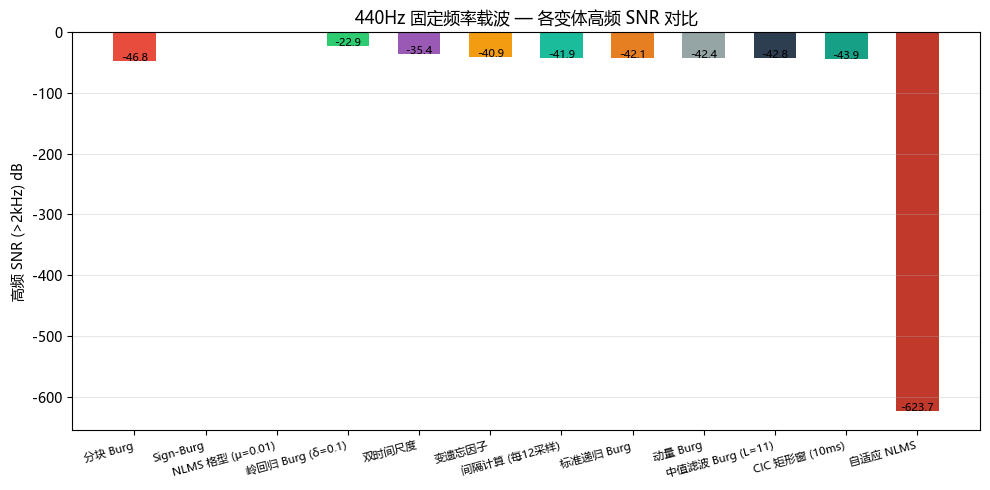

In [15]:
# ------------------------------------------------------------
# 6a. SNR 对比
# ------------------------------------------------------------
def compute_snr(original, reconstructed):
    noise = original - reconstructed
    return 10 * np.log10(np.sum(original**2) / (np.sum(noise**2) + 1e-30))


from scipy.signal import butter, sosfilt

def high_freq_snr(original, reconstructed, fs, cutoff=2000):
    sos = butter(4, cutoff, btype='high', fs=fs, output='sos')
    orig_hf = sosfilt(sos, original)
    recon_hf = sosfilt(sos, reconstructed)
    return compute_snr(orig_hf, recon_hf)


print(f"=== 440Hz 固定频率载波 — SNR 对比 ===\n")
print(f"{'方法':<22} {'SNR (dB)':<12} {'高频SNR (dB)':<15}")
print("-" * 49)

snr_block_ref = compute_snr(x, synth_block)
hf_snr_block_ref = high_freq_snr(x, synth_block, fs)
print(f"{'分块 Burg (参考)':<22} {snr_block_ref:<12.2f} {hf_snr_block_ref:<15.2f}")

for name, _ in variants:
    snr_val = compute_snr(x, results[name])
    hf_snr = high_freq_snr(x, results[name], fs)
    print(f"{name:<22} {snr_val:<12.2f} {hf_snr:<15.2f}")


# ----- 柱状图 -----
print(f"\n=== 高频段 SNR 排名 ===")
rankings = [(name, high_freq_snr(x, results[name], fs)) for name, _ in variants]
rankings.sort(key=lambda r: r[1], reverse=True)

fig, ax = plt.subplots(figsize=(10, 5))
names = [r[0] for r in rankings]
snrs = [r[1] for r in rankings]
all_names = ['分块 Burg'] + names
all_snrs = [hf_snr_block_ref] + snrs
bar_colors = ['#e74c3c'] + [colors[i % len(colors)] for i in range(len(names))]

bars = ax.bar(range(len(all_names)), all_snrs, color=bar_colors, width=0.6)
ax.set_xticks(range(len(all_names)))
ax.set_xticklabels(all_names, fontsize=8, rotation=15, ha='right')
ax.set_ylabel('高频 SNR (>2kHz) dB')
ax.set_title(f'440Hz 固定频率载波 — 各变体高频 SNR 对比')
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, all_snrs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()


---
## 7. 音频播放对比

> ⚠️ 以下单元格包含 `display(Audio(...))`，运行后会播放音频。


In [16]:
# ------------------------------------------------------------
# 7a. 音频播放
# ------------------------------------------------------------
print("原始信号（前 1 秒）:")
display(Audio(x, rate=fs))

print("\n分块 Burg (参考) — 440Hz 载波:")
s = synth_block / (np.max(np.abs(synth_block)) + 1e-30)
display(Audio(s, rate=fs))

for name, _ in variants:
    s = results[name]
    s_norm = s / (np.max(np.abs(s)) + 1e-30)
    hf = high_freq_snr(x, s, fs)
    print(f"\n{name} (HF-SNR={hf:.1f}dB) — 440Hz 载波:")
    display(Audio(s_norm, rate=fs))


原始信号（前 1 秒）:



分块 Burg (参考) — 440Hz 载波:



标准递归 Burg (HF-SNR=-42.1dB) — 440Hz 载波:



间隔计算 (每12采样) (HF-SNR=-41.9dB) — 440Hz 载波:



CIC 矩形窗 (10ms) (HF-SNR=-43.9dB) — 440Hz 载波:


...


动量 Burg (HF-SNR=-42.4dB) — 440Hz 载波:



岭回归 Burg (δ=0.1) (HF-SNR=-22.9dB) — 440Hz 载波:



双时间尺度 (HF-SNR=-35.4dB) — 440Hz 载波:



中值滤波 Burg (L=11) (HF-SNR=-42.8dB) — 440Hz 载波:



自适应 NLMS (HF-SNR=-623.7dB) — 440Hz 载波:
